# **Sales Analysis**

In [50]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [51]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [52]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [53]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
506434,2024-07-21 17:03:19.802531,2024,7,Sun,Afternoon,Yes,Oscar Scott,Male,19,18-24,Regular,Germany,Completed,Home,Kitchen,130.74,Premium,3,Small Basket,392.22,0.00,0,No Discount,No,392.22,High,225.72,57.55,Debit Card,Economy,21.65,5.52,1,Fast,Germany,Domestic,4,53.50,Medium,Yes,45.40,High,12,Yes,1.20,Low,Desktop,Email,Referral
675358,2024-02-09 09:08:23.845831,2024,2,Fri,Morning,No,Oscar Craig,Male,18,18-24,Premium,Netherlands,Completed,Electronics,Smartphones,83.30,Mid-Range,5,Bulk,416.50,20.82,5,Low Discount,Yes,395.68,High,187.63,47.42,Apple Pay,Standard,22.63,5.72,8,Slow,Netherlands,Domestic,2,26.80,Low,No,26.20,Medium,13,No,59.00,Medium,Tablet,Email,Direct
971483,2024-10-09 01:21:57.316318,2024,10,Wed,Night,No,Tony Hudson,Male,22,18-24,Regular,Netherlands,Completed,Clothing,Kids Wear,123.72,Premium,1,Single,123.72,18.56,15,Medium Discount,Yes,105.16,Medium,39.26,37.33,Debit Card,Standard,9.58,9.11,10,Slow,Netherlands,Domestic,2,55.40,Medium,Yes,51.40,High,1,Yes,42.70,Medium,Mobile,Instagram,Email
748343,2025-12-16 04:17:51.709635,2025,12,Tue,Night,No,Nathan Garcia,Male,29,25-34,Premium,United Kingdom,Completed,Electronics,Smartphones,262.88,Luxury,2,Small Basket,525.76,52.58,10,Low Discount,Yes,473.18,High,131.04,27.69,Bank Transfer,Next Day,18.37,3.88,14,Slow,United Kingdom,Domestic,1,27.30,Low,No,52.90,High,15,Yes,3.70,Low,Tablet,Affiliate,Email
821887,2024-06-02 03:02:13.314048,2024,6,Sun,Night,Yes,Alexander Nelson,Male,35,35-44,Regular,Canada,Completed,Health,Medical Devices,171.23,Premium,1,Single,171.23,8.56,5,Low Discount,Yes,162.67,Medium,48.07,29.55,Debit Card,Standard,0.79,0.49,10,Slow,Canada,Domestic,5,41.10,Medium,Yes,7.40,Low,4,No,1.60,Low,Desktop,Email,Social
291696,2024-07-09 10:44:43.896134,2024,7,Tue,Morning,No,Pamela Johns,Female,44,35-44,Regular,Germany,Completed,Clothing,Womens Wear,82.31,Mid-Range,3,Small Basket,246.93,37.04,15,Medium Discount,Yes,209.89,Medium,87.31,41.60,Debit Card,Standard,19.00,9.05,9,Slow,Germany,Domestic,3,42.70,Medium,Yes,4.20,Low,14,No,99.20,High,Mobile,Organic,Search
119078,2025-05-13 09:59:04.349842,2025,5,Tue,Morning,No,Erik Peters,Male,33,25-34,Premium,France,Processing,Health,Fitness,89.92,Mid-Range,1,Single,89.92,0.00,0,No Discount,No,89.92,Low,42.57,47.34,Debit Card,Economy,8.01,8.91,6,Standard,France,Domestic,4,19.20,Low,Yes,1.10,Low,17,Yes,88.20,High,Mobile,Organic,Direct
42362,2024-11-15 13:21:19.686882,2024,11,Fri,Afternoon,No,Kaitlin Lopez,Female,55,55-64,Premium,United States,Processing,Home,Kitchen,164.66,Premium,3,Small Basket,493.98,0.00,0,No Discount,No,493.98,High,259.44,52.52,Debit Card,Standard,11.94,2.42,10,Slow,United States,Domestic,3,91.10,High,Yes,22.40,Medium,17,Yes,49.20,Medium,Tablet,Organic,Search
726236,2025-01-02 22:35:43.287823,2025,1,Thu,Evening,No,Chad Roberson,Male,22,18-24,Premium,Spain,Completed,Electronics,Accessories,30.55,Budget,3,Small Basket,91.65,4.58,5,Low Discount,Yes,87.07,Low,45.76,52.56,Apple Pay,Standard,4.59,5.27,3,Fast,Spain,Domestic,3,57.70,Medium,No,28.80,Medium,1,No,22.20,Low,Tablet,Organic,Search
268094,2024-06-28 07:09:02.073828,2024,6,Fri,Morning,No,Kristen Allen,Female,66,65+,Regular,United States,Completed,Clothing,Kids Wear,80.96,Mid-Range,1,Single,80.96,8.10,10,Low Discount,Yes,72.86,Low,28.52,39.14,Debit Card,Next Day,14.2

## 1.1 Revenue by Time

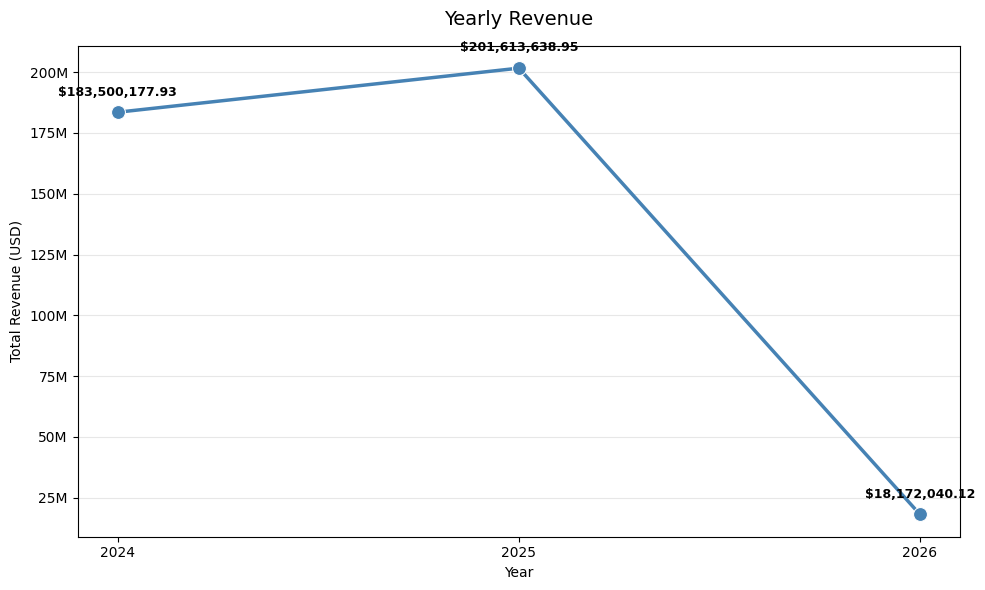

In [54]:
# 1.1.1 Yearly Revenue

yearly_revenue = (
    sales_df.groupby('order_year')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

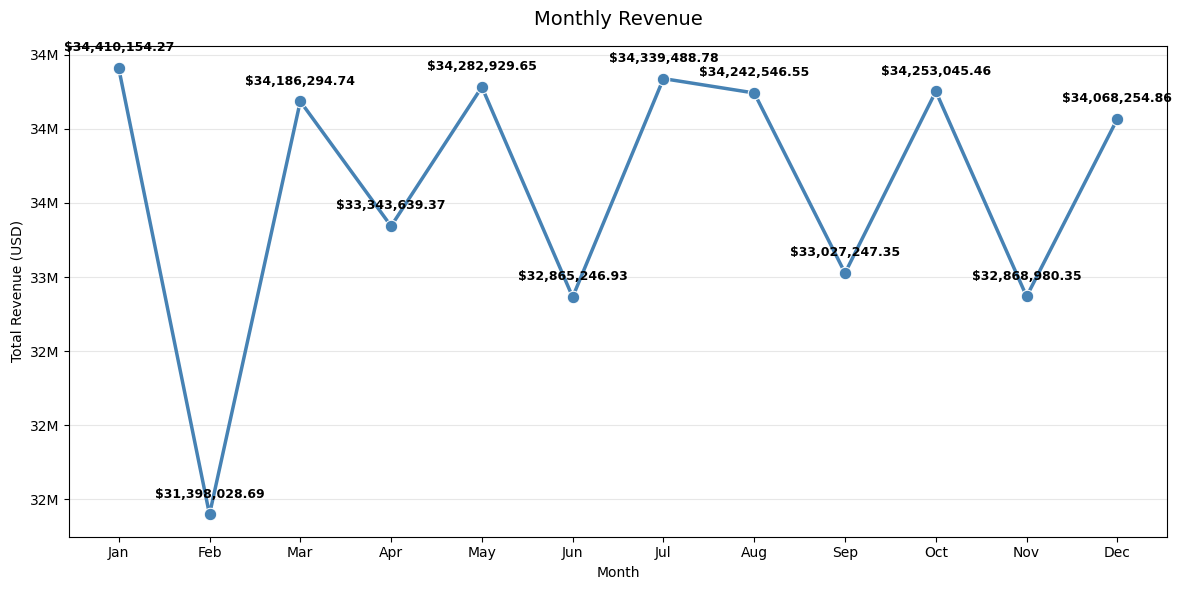

In [55]:
# 1.1.2 Monthly Revenue

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

sales_df['order_month'] = sales_df['order_month'].map(month_map)

monthly_revenue = (
    sales_df.groupby('order_month')['revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

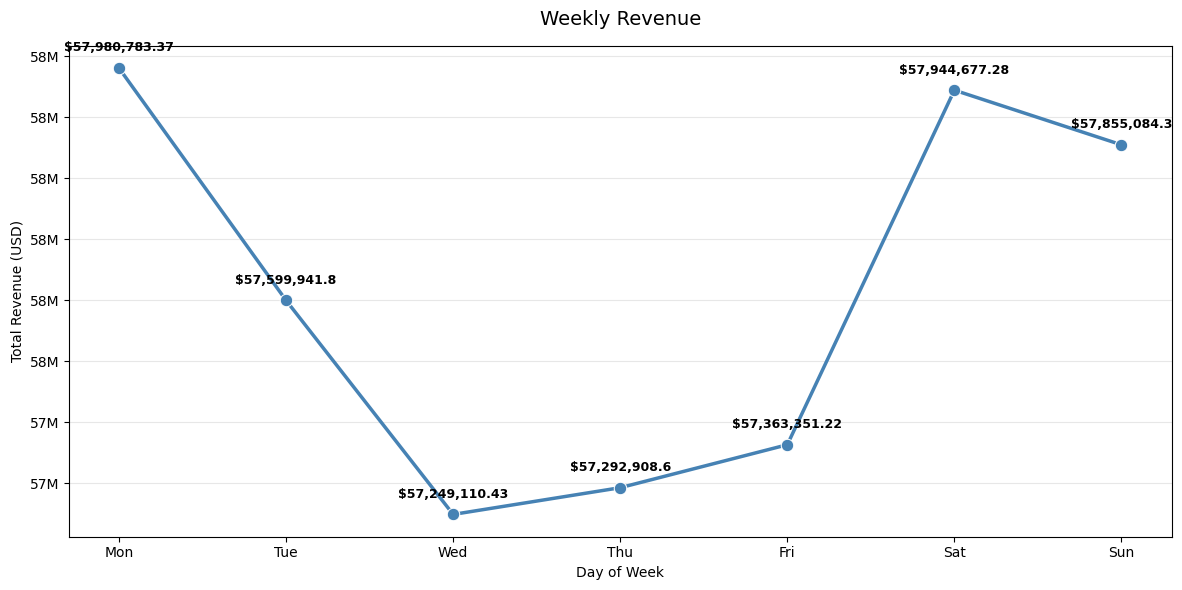

In [56]:
# 1.1.3 Day of Week Revenue

day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Weekly Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

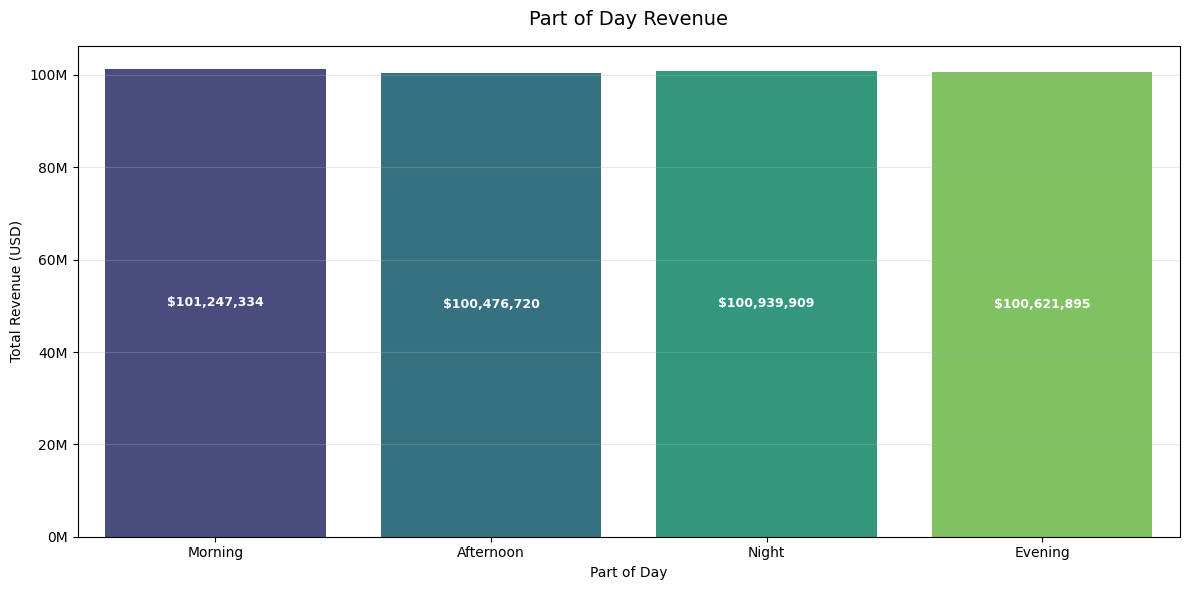

In [57]:
# 1.1.4 Part of Day Revenue

part_day_revenue = (
    sales_df.groupby('part_day')['revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

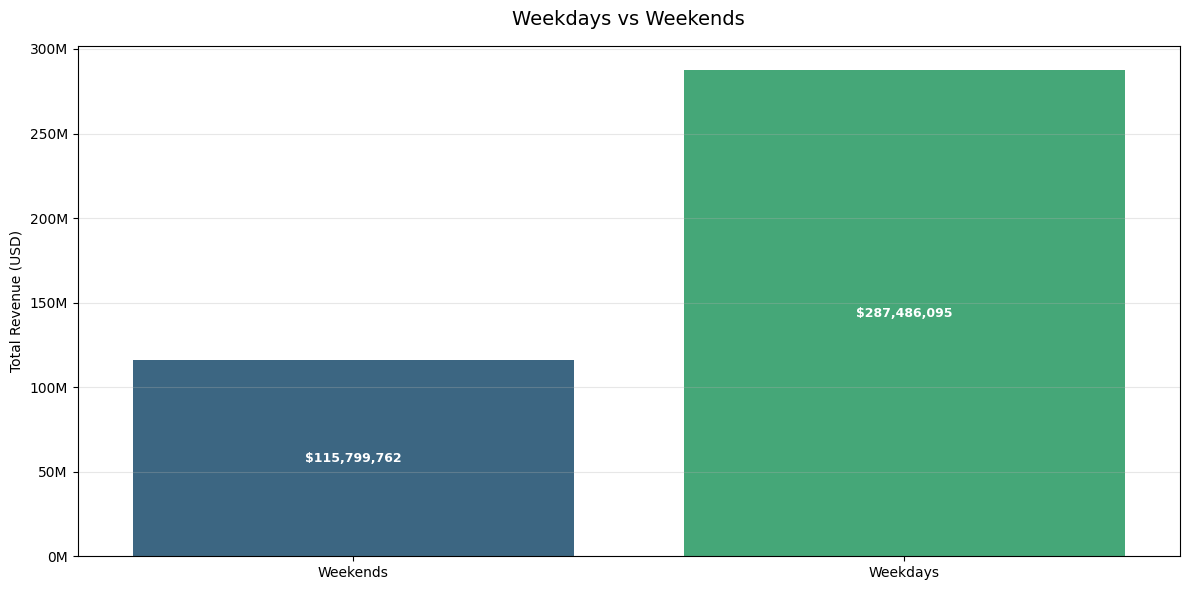

In [58]:
# 1.1.5 Weekend vs Weekedays

is_weekend_revenue = (
    sales_df.groupby('is_weekend')['revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Revenue by Category and Sub-Category

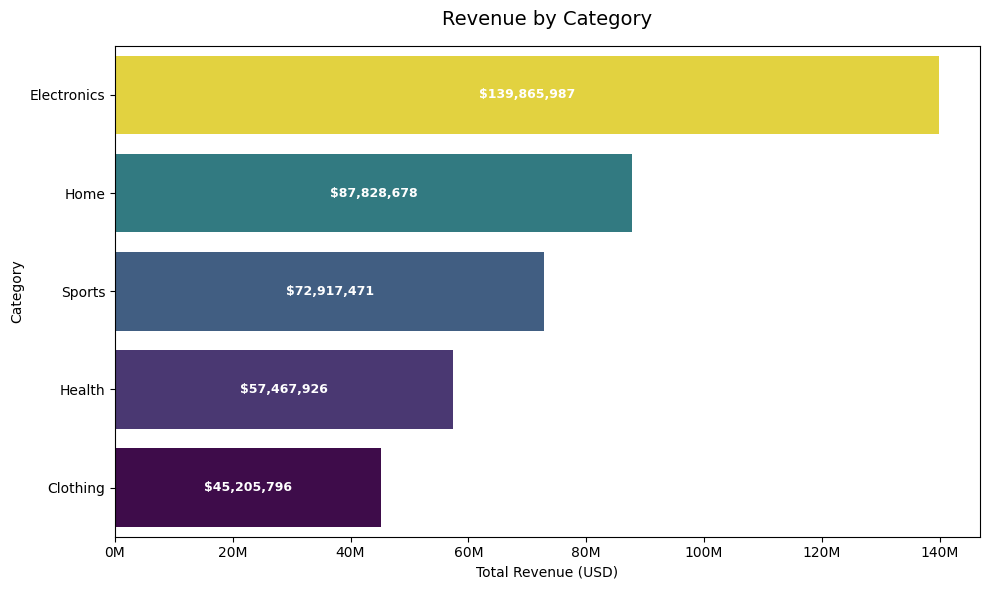

In [59]:
# 1.2.1 Revenue per Category

category_revenue = (
    sales_df.groupby('category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

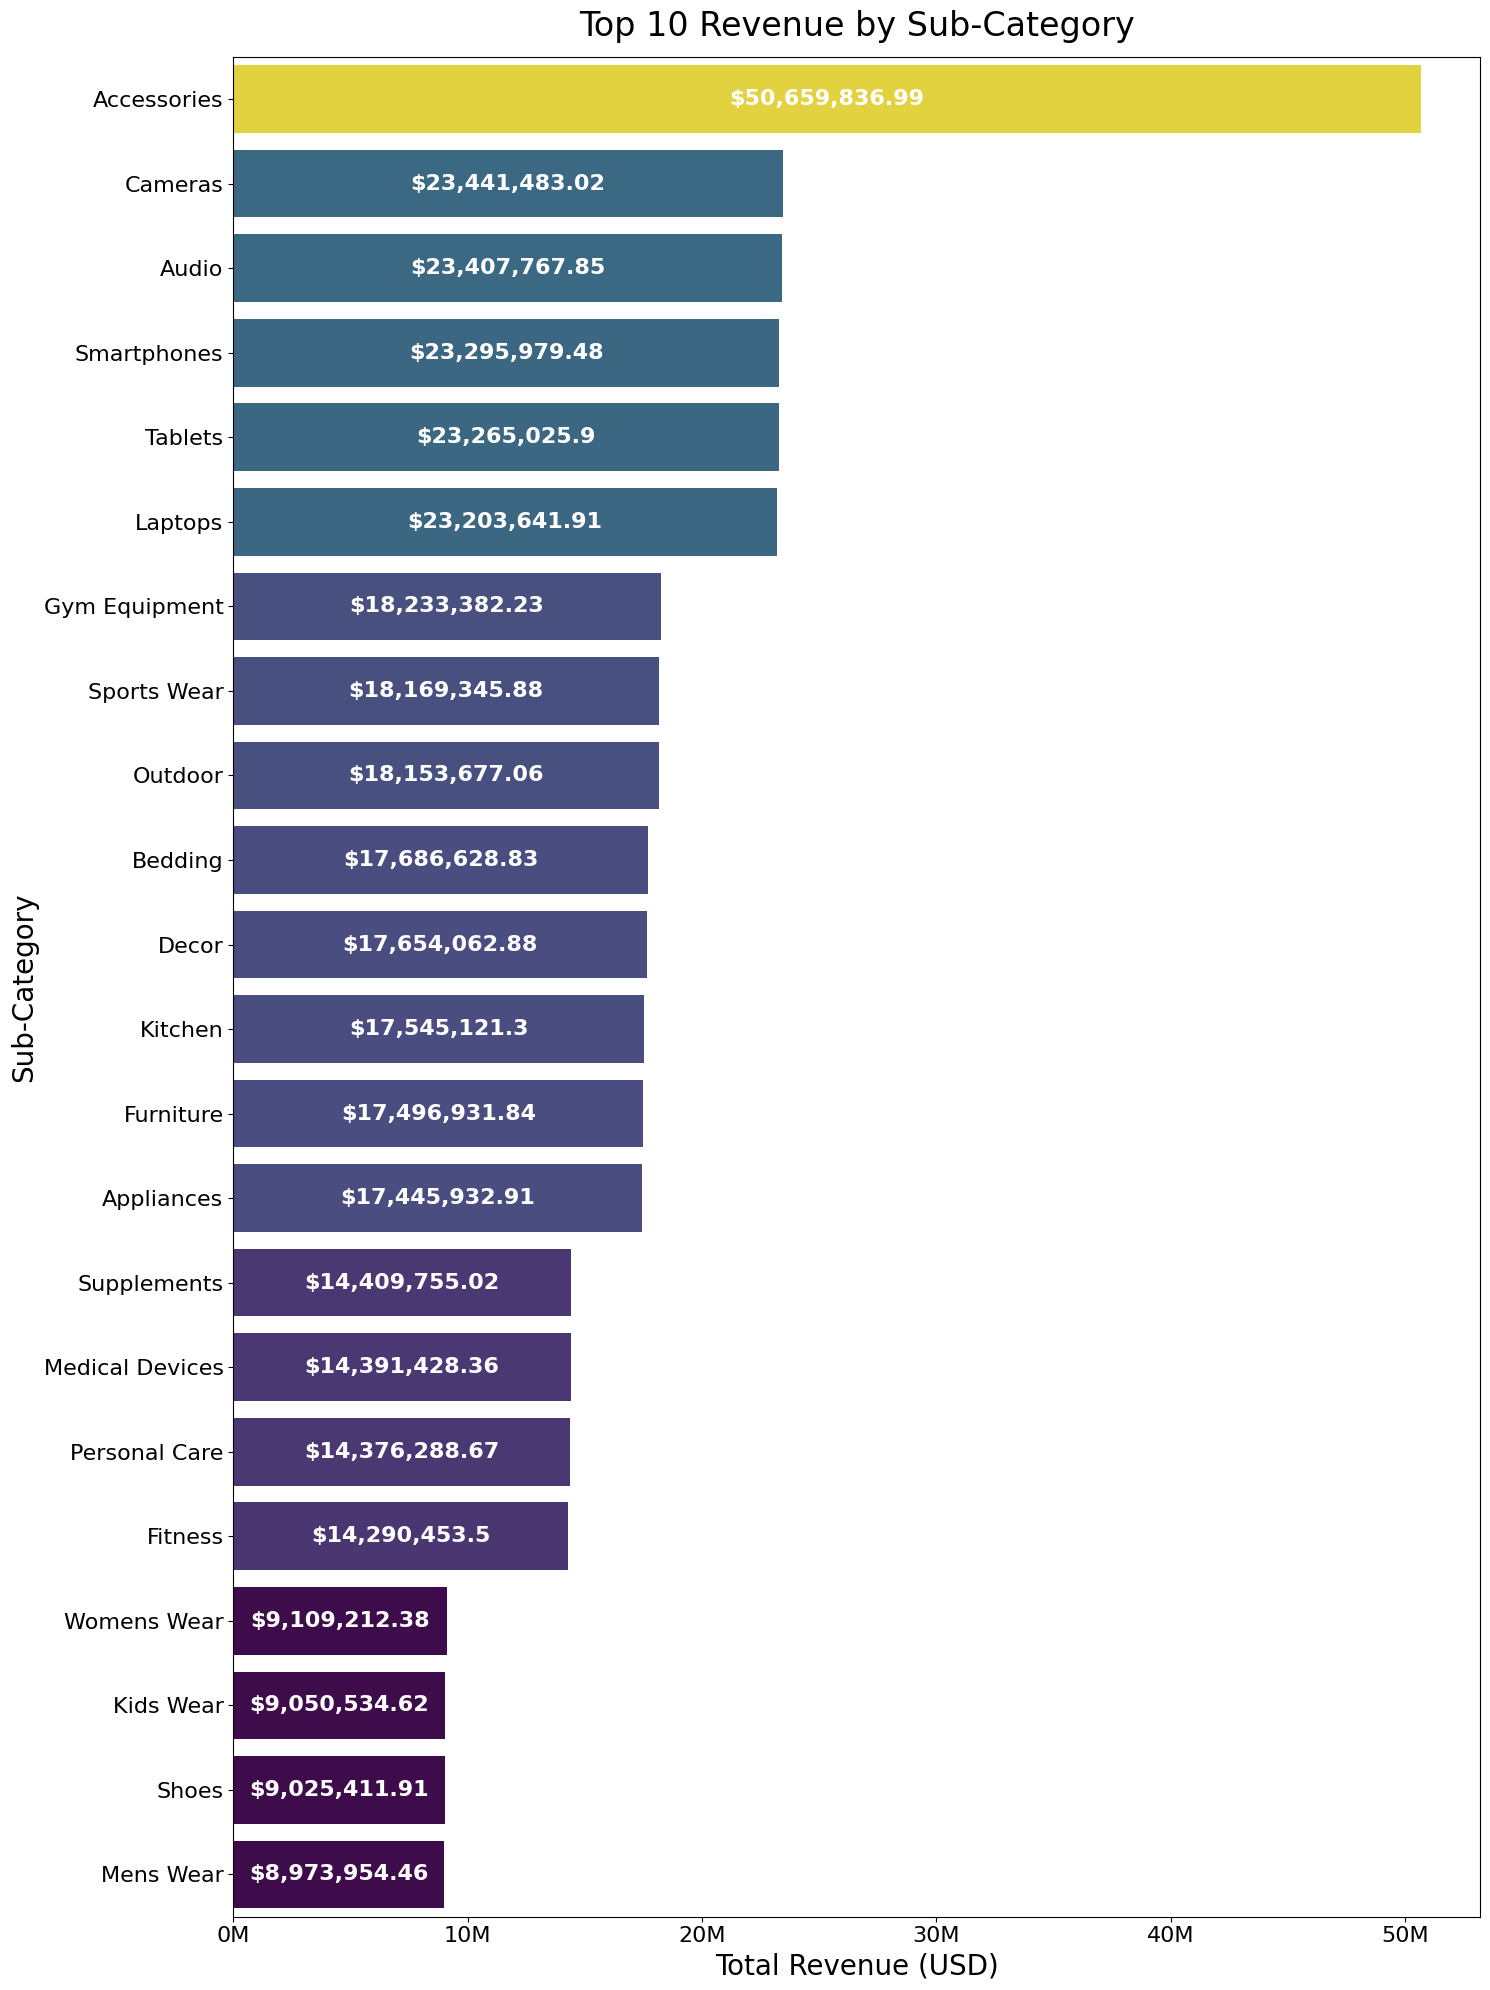

In [60]:
# 1.2.1 Top 10 Revenue Sub Category

subcategory_revenue = (
    sales_df.groupby('sub_category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

## 1.3 Revenue by Country

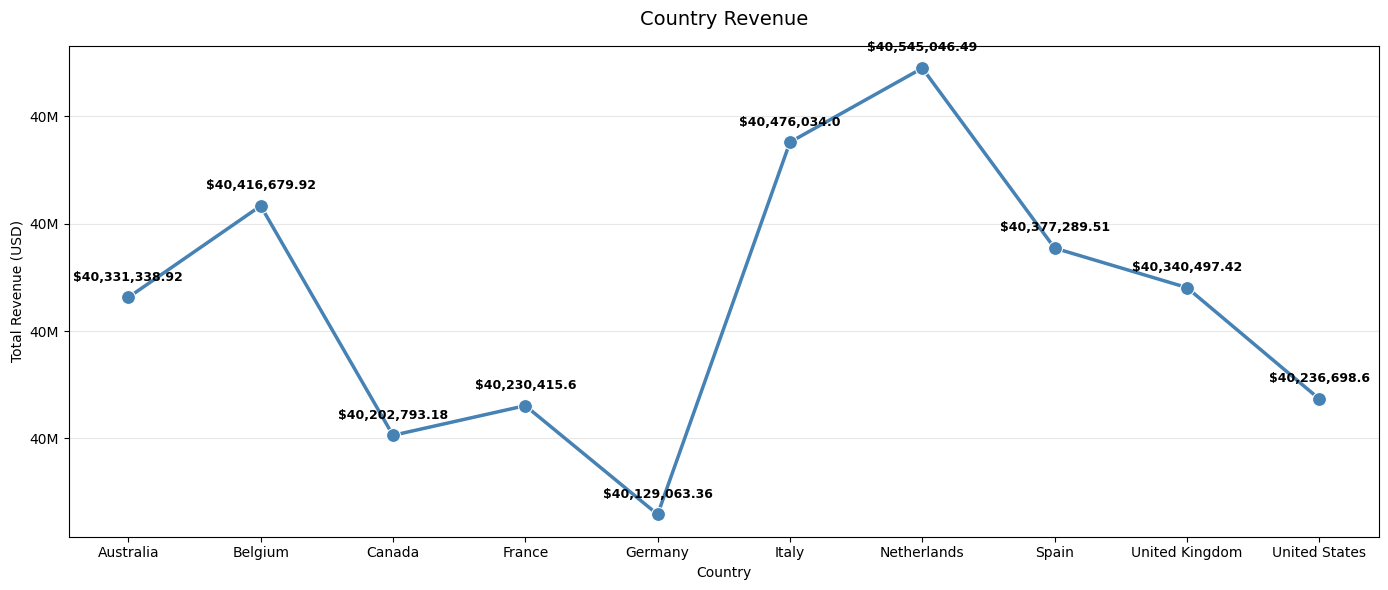

In [61]:
# 1.3.1 Country Revenue

country_revenue = (
    sales_df.groupby('country')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=country_revenue,
    x='country',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(country_revenue['country'], country_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Country Revenue', fontsize=14, pad=15)
plt.xlabel('Country')
plt.ylabel('Total Revenue (USD)')
plt.xticks(country_revenue['country'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

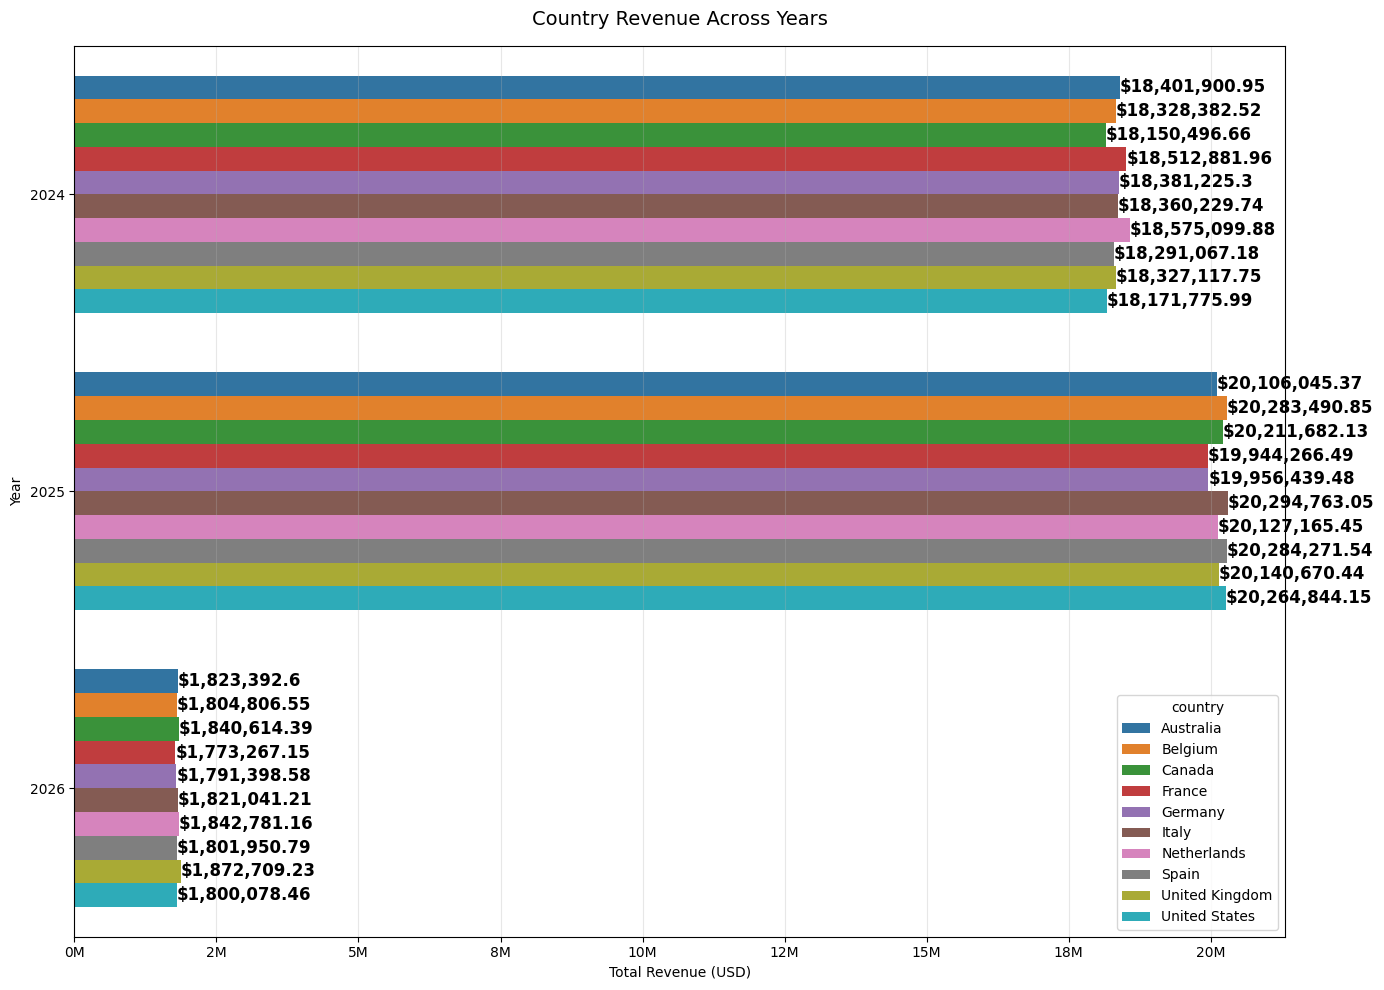

In [62]:
# 1.3.1 Country Revenue Across Years

country_yearly_revenue = sales_df.groupby(
    ['order_year', 'country']
)['revenue_usd'].sum().reset_index()

plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=country_yearly_revenue,
    x='revenue_usd',
    y='order_year',
    palette='tab10',
    hue='country',
    orient='h'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold',
    )

plt.title('Country Revenue Across Years', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Year')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.4 Revenue by Order Value Segment

C:\Users\User\AppData\Local\Temp\ipykernel_29984\653523291.py:9: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(


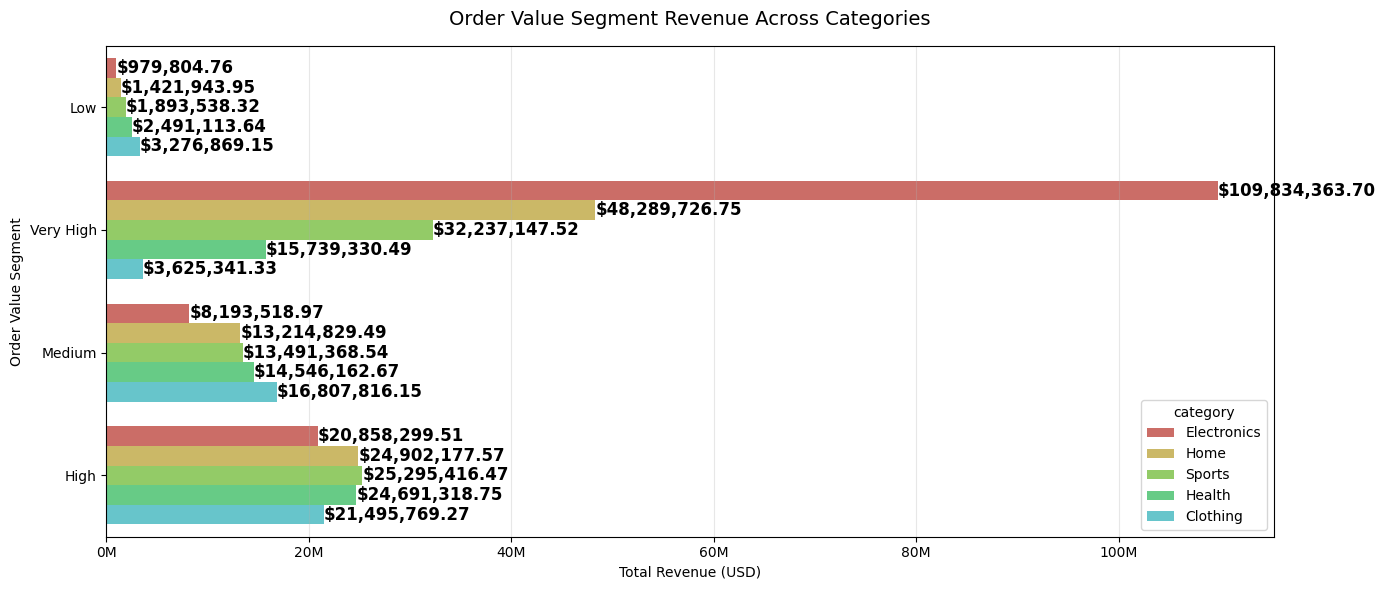

In [63]:
# 1.4.1 Order Value Segment Revenue Across Categories

order_value_segment_revenue = sales_df.groupby(
    ['order_value_segment', 'category']
)['revenue_usd'].sum().reset_index().sort_values('revenue_usd')

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='revenue_usd',
    y='order_value_segment',
    hue='category',
    palette=sns.color_palette('hls',8),
    # order=f"{['Very High', 'High', 'Medium', 'Low']}"
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Order Value Segment Revenue Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.5 Customers

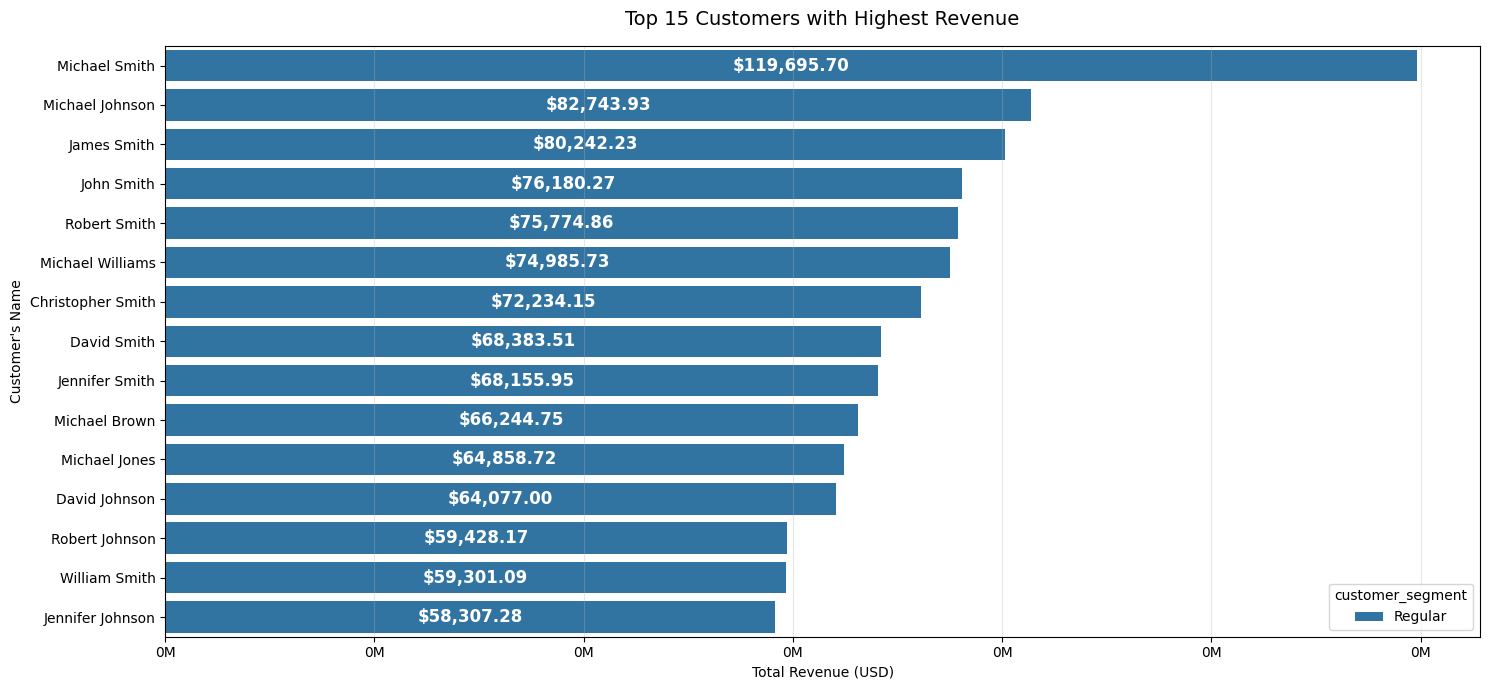

In [64]:
# 1.5.1 Top 15 Customers with Highest Revenue and their Customer Segment

customers_highest_revenue = sales_df.groupby(['customer_name','customer_segment'])['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customers_highest_revenue,
    x='revenue_usd',
    y='customer_name',
    hue='customer_segment',
    orient='h',
    palette='tab10'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Top 15 Customers with Highest Revenue', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Customer's Name")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

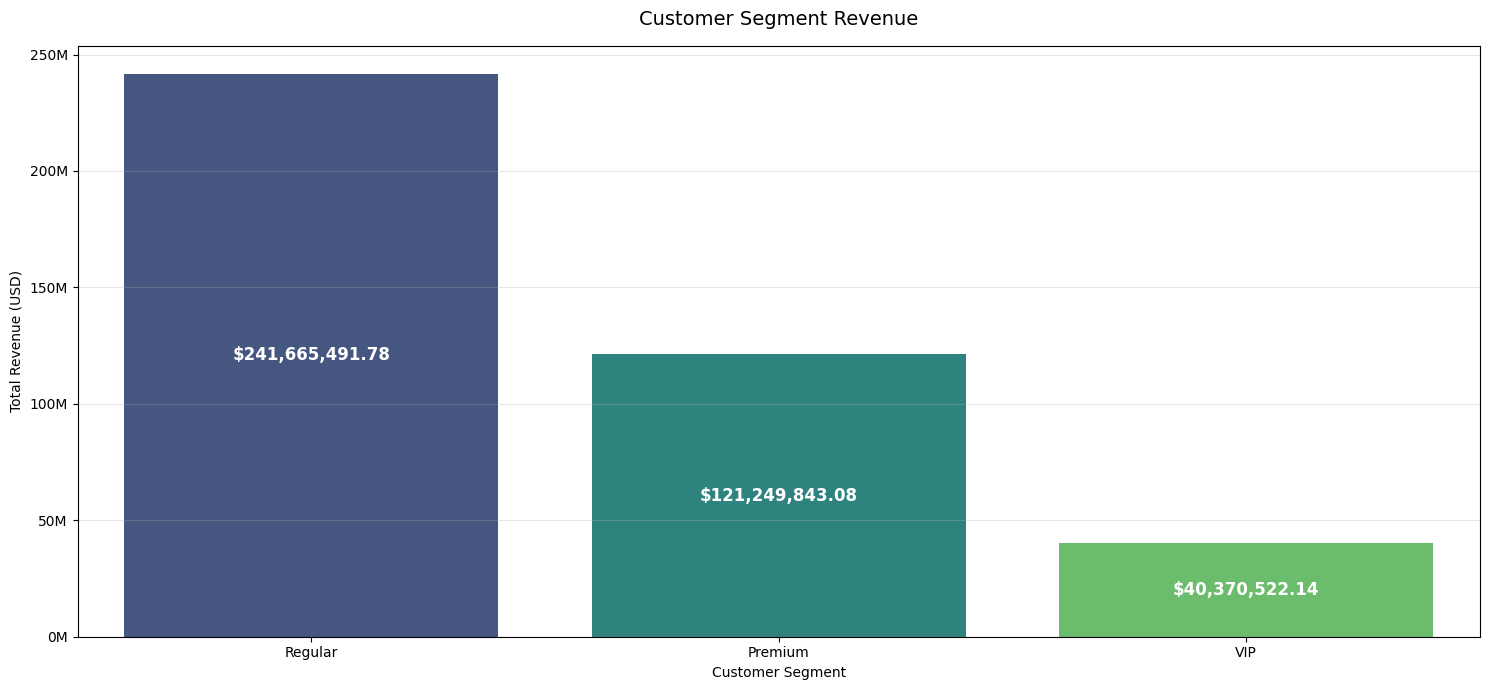

In [65]:
# 1.5.2 Customer Segment Revenue

customer_segment_revenue = sales_df.groupby('customer_segment')['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_usd',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Customer Segment Revenue', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Total Revenue (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)